# PcAbuser - Ensemble XGBoost + MLP

**Strategia:** Ensemble ibrido con voting ponderato

**Modelli base:**
- XGBoost v2 (ROC AUC: 0.9307, F1: 0.7833)
- MLP Baseline (ROC AUC: 0.9200, F1: 0.7662)

**Logica di ensemble:**
1. XGBoost fa predizione primaria
2. Se predizione incerta (0.4 < prob < 0.6) → consulta MLP
3. Weighted voting: XGBoost (peso 0.6) + MLP (peso 0.4)

**Dataset:** processed_v4_hybrid (43 features, binary classification)

## 1. Setup

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pickle
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

# Device per MLP
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Device: {device} ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Device: {device} (Metal Performance Shaders)")
else:
    device = torch.device('cpu')
    print(f"Device: {device}")

print(f"PyTorch version: {torch.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Device: mps (Metal Performance Shaders)
PyTorch version: 2.9.0
XGBoost version: 3.1.1


## 2. Caricamento Dati

In [128]:
print("Caricamento dataset processed_v4_hybrid...\n")

X_train = pd.read_csv('../data/processed_v4_hybrid/X_train.csv')
X_test = pd.read_csv('../data/processed_v4_hybrid/X_test.csv')
y_train = pd.read_csv('../data/processed_v4_hybrid/y_train.csv')['BinaryIncidentGrade']
y_test = pd.read_csv('../data/processed_v4_hybrid/y_test.csv')['BinaryIncidentGrade']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nDistribuzione y_test:")
print(y_test.value_counts(normalize=True))

Caricamento dataset processed_v4_hybrid...

X_train: (304848, 43)
X_test: (149537, 43)

Distribuzione y_test:
BinaryIncidentGrade
0    0.708768
1    0.291232
Name: proportion, dtype: float64


## 3. Definizione Architettura MLP

In [129]:
class MLP(nn.Module):
    """Stessa architettura di 8-MLP.ipynb"""
    def __init__(self, input_dim, dropout=0.3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

print("✅ Architettura MLP definita")

✅ Architettura MLP definita


## 4. Caricamento Modelli Pre-addestrati

In [130]:
print("Caricamento XGBoost v2...\n")

# Carica XGBoost
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../models/xgboost_v2/model.json')
print("✅ XGBoost v2 caricato")

# Carica metriche XGBoost
with open('../models/xgboost_v2/metrics.json', 'r') as f:
    xgb_metrics = json.load(f)
print(f"   ROC AUC: {xgb_metrics['test_roc_auc']:.4f}")
print(f"   F1-Score: {xgb_metrics['test_f1_score']:.4f}")

Caricamento XGBoost v2...

✅ XGBoost v2 caricato
   ROC AUC: 0.9307
   F1-Score: 0.7833


In [131]:
print("\nCaricamento MLP Baseline...\n")

# Inizializza MLP con stessa architettura
input_dim = X_train.shape[1]
mlp_model = MLP(input_dim, dropout=0.3).to(device)

# Carica pesi
checkpoint = torch.load('../models/mlp_baseline/model.pth', map_location=device)
mlp_model.load_state_dict(checkpoint['model_state_dict'])
mlp_model.eval()
print("✅ MLP Baseline caricato")

# Carica metriche MLP
with open('../models/mlp_baseline/metrics.json', 'r') as f:
    mlp_metrics = json.load(f)
print(f"   ROC AUC: {mlp_metrics['test_metrics']['roc_auc']:.4f}")
print(f"   F1-Score: {mlp_metrics['test_metrics']['f1_score']:.4f}")


Caricamento MLP Baseline...

✅ MLP Baseline caricato
   ROC AUC: 0.9200
   F1-Score: 0.7662


## 5. Preprocessing per MLP (Standardizzazione)

In [132]:
# MLP richiede standardizzazione (XGBoost no)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

print("✅ Dati standardizzati per MLP")
print(f"   Shape: {X_test_tensor.shape}")

✅ Dati standardizzati per MLP
   Shape: torch.Size([149537, 43])


## 6. Predizioni dei Modelli Base

In [133]:
print("Generazione predizioni XGBoost...\n")

# Predizioni XGBoost
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print(f"✅ XGBoost: {len(xgb_probs)} predizioni")
print(f"   Probabilità media: {xgb_probs.mean():.4f}")
print(f"   Std: {xgb_probs.std():.4f}")

Generazione predizioni XGBoost...

✅ XGBoost: 149537 predizioni
   Probabilità media: 0.3627
   Std: 0.3466


In [134]:
print("\nGenerazione predizioni MLP...\n")

# Predizioni MLP
with torch.no_grad():
    mlp_logits = mlp_model(X_test_tensor)
    mlp_probs = torch.sigmoid(mlp_logits).cpu().numpy().flatten()
    mlp_preds = (mlp_probs >= 0.5).astype(int)

print(f"✅ MLP: {len(mlp_probs)} predizioni")
print(f"   Probabilità media: {mlp_probs.mean():.4f}")
print(f"   Std: {mlp_probs.std():.4f}")


Generazione predizioni MLP...

✅ MLP: 149537 predizioni
   Probabilità media: 0.5890
   Std: 0.2894


## 7. Ensemble PcAbuser - Weighted Voting

In [135]:
print("Creazione Ensemble PcAbuser...\n")

# Parametri ensemble
UNCERTAINTY_LOW = 0.05
UNCERTAINTY_HIGH = 0.6
XGB_WEIGHT = 0.6
MLP_WEIGHT = 0.4

# Identifica predizioni incerte di XGBoost
uncertain_mask = (xgb_probs >= UNCERTAINTY_LOW) & (xgb_probs <= UNCERTAINTY_HIGH)
n_uncertain = uncertain_mask.sum()

print(f"Predizioni incerte XGBoost: {n_uncertain} / {len(xgb_probs)} ({100*n_uncertain/len(xgb_probs):.2f}%)")
print(f"\nPesi: XGBoost={XGB_WEIGHT}, MLP={MLP_WEIGHT}")

# Ensemble predictions
ensemble_probs = xgb_probs.copy()

# Weighted voting per predizioni incerte
ensemble_probs[uncertain_mask] = (
    XGB_WEIGHT * xgb_probs[uncertain_mask] + 
    MLP_WEIGHT * mlp_probs[uncertain_mask]
)

ensemble_preds = (ensemble_probs >= 0.5).astype(int)

print(f"\n✅ Ensemble completato")
print(f"   Predizioni totali: {len(ensemble_preds)}")
print(f"   Predizioni modificate: {n_uncertain}")

Creazione Ensemble PcAbuser...

Predizioni incerte XGBoost: 80228 / 149537 (53.65%)

Pesi: XGBoost=0.6, MLP=0.4

✅ Ensemble completato
   Predizioni totali: 149537
   Predizioni modificate: 80228


## 8. Valutazione Performance

In [136]:
print("="*70)
print("PERFORMANCE TEST SET - PcAbuser Ensemble")
print("="*70)

print("\nClassification Report:")
print(classification_report(
    y_test, ensemble_preds,
    target_names=['Non-TP', 'TP'],
    digits=4
))

# Calcola metriche
accuracy = accuracy_score(y_test, ensemble_preds)
precision = precision_score(y_test, ensemble_preds)
recall = recall_score(y_test, ensemble_preds)
f1 = f1_score(y_test, ensemble_preds)
roc_auc = roc_auc_score(y_test, ensemble_probs)

print(f"\nACCURACY:          {accuracy:.4f}")
print(f"PRECISION:         {precision:.4f}")
print(f"RECALL:            {recall:.4f}")
print(f"F1-SCORE:          {f1:.4f}")
print(f"ROC AUC:           {roc_auc:.4f}")

PERFORMANCE TEST SET - PcAbuser Ensemble

Classification Report:
              precision    recall  f1-score   support

      Non-TP     0.9092    0.9027    0.9059    105987
          TP     0.7672    0.7806    0.7738     43550

    accuracy                         0.8671    149537
   macro avg     0.8382    0.8416    0.8399    149537
weighted avg     0.8678    0.8671    0.8675    149537


ACCURACY:          0.8671
PRECISION:         0.7672
RECALL:            0.7806
F1-SCORE:          0.7738
ROC AUC:           0.9207


## 9. Confronto con Modelli Base

In [137]:
# Calcola metriche modelli base
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_roc_auc = roc_auc_score(y_test, xgb_probs)

mlp_acc = accuracy_score(y_test, mlp_preds)
mlp_f1 = f1_score(y_test, mlp_preds)
mlp_roc_auc = roc_auc_score(y_test, mlp_probs)

# Tabella comparativa
comparison = pd.DataFrame({
    'Model': ['XGBoost v2', 'MLP Baseline', 'PcAbuser Ensemble'],
    'Accuracy': [xgb_acc, mlp_acc, accuracy],
    'F1-Score': [xgb_f1, mlp_f1, f1],
    'ROC AUC': [xgb_roc_auc, mlp_roc_auc, roc_auc]
})

print("\n" + "="*70)
print("CONFRONTO MODELLI")
print("="*70)
print(comparison.to_string(index=False))

# Delta improvements
print(f"\n📈 Miglioramento rispetto a XGBoost:")
print(f"   Accuracy: {(accuracy - xgb_acc)*100:+.2f}%")
print(f"   F1-Score: {(f1 - xgb_f1)*100:+.2f}%")
print(f"   ROC AUC:  {(roc_auc - xgb_roc_auc)*100:+.2f}%")


CONFRONTO MODELLI
            Model  Accuracy  F1-Score  ROC AUC
       XGBoost v2  0.878632  0.783252 0.930732
     MLP Baseline  0.598153  0.541916 0.815119
PcAbuser Ensemble  0.867123  0.773834 0.920692

📈 Miglioramento rispetto a XGBoost:
   Accuracy: -1.15%
   F1-Score: -0.94%
   ROC AUC:  -1.00%


## 10. Confusion Matrix

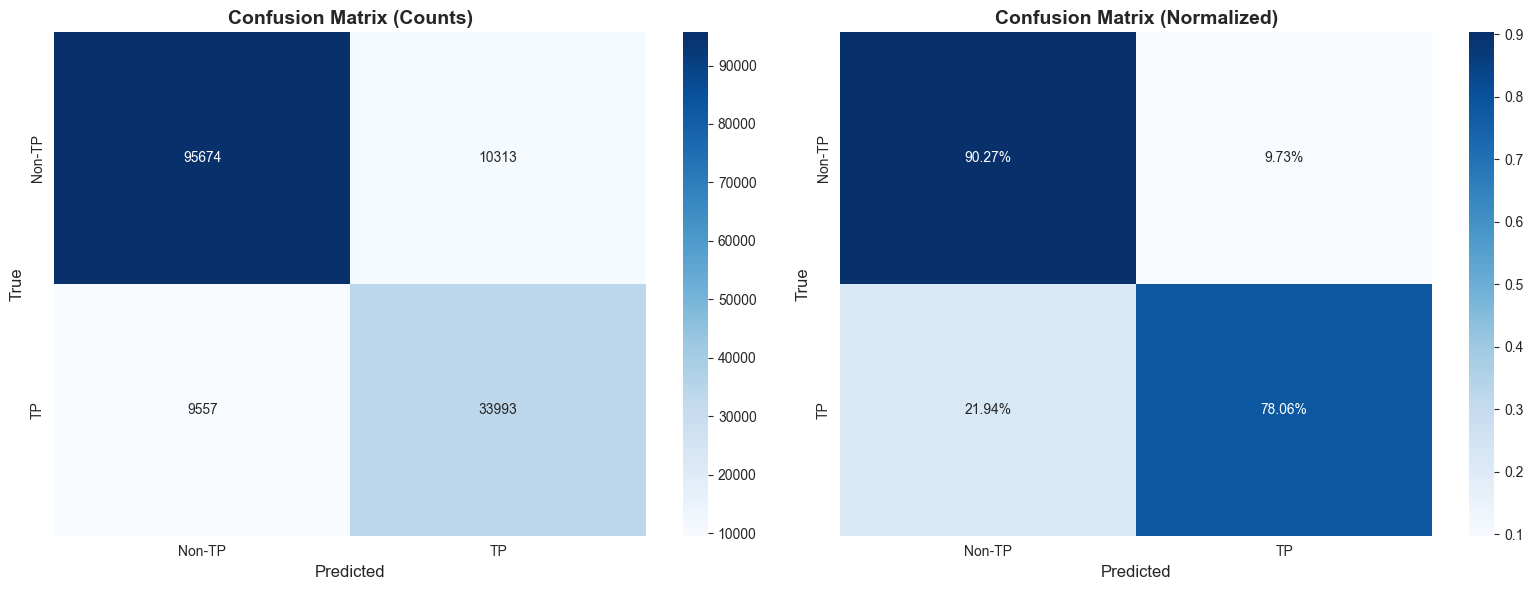

In [138]:
cm = confusion_matrix(y_test, ensemble_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-TP', 'TP'],
            yticklabels=['Non-TP', 'TP'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Non-TP', 'TP'],
            yticklabels=['Non-TP', 'TP'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

## 11. ROC Curve

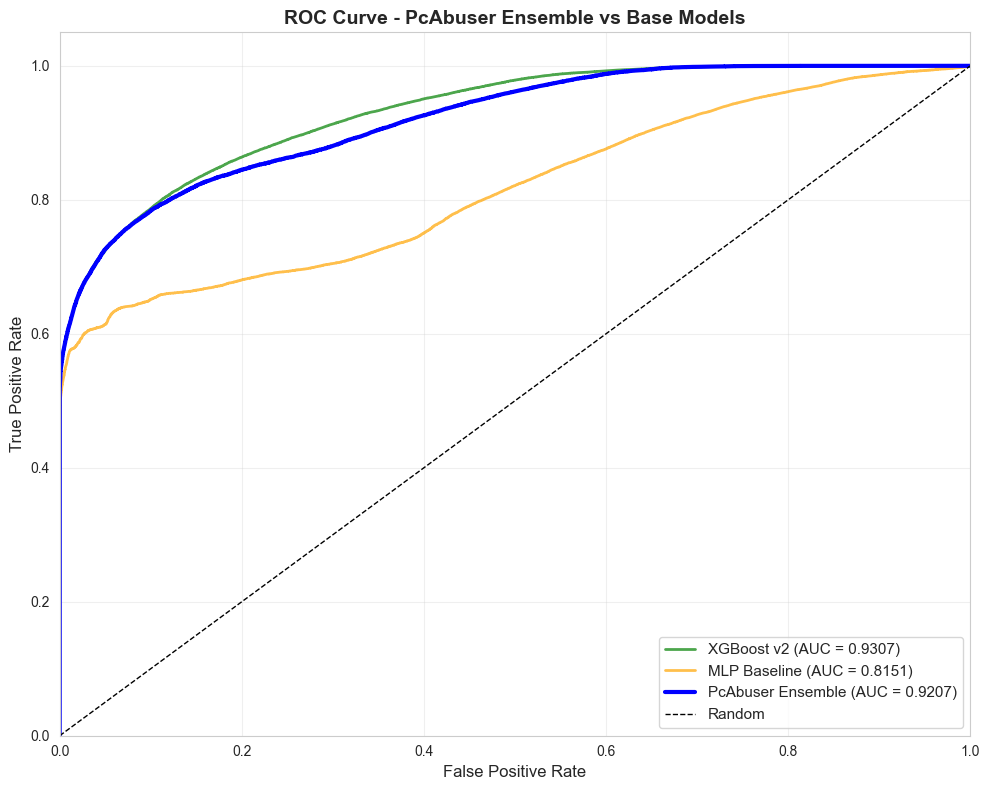

In [139]:
# Calcola ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_probs)
fpr_ens, tpr_ens, _ = roc_curve(y_test, ensemble_probs)

plt.figure(figsize=(10, 8))

# Plot tutte le curve
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, alpha=0.7,
         label=f'XGBoost v2 (AUC = {xgb_roc_auc:.4f})')
plt.plot(fpr_mlp, tpr_mlp, color='orange', lw=2, alpha=0.7,
         label=f'MLP Baseline (AUC = {mlp_roc_auc:.4f})')
plt.plot(fpr_ens, tpr_ens, color='blue', lw=3,
         label=f'PcAbuser Ensemble (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - PcAbuser Ensemble vs Base Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Analisi Predizioni Incerte

In [140]:
print("="*70)
print("ANALISI PREDIZIONI INCERTE")
print("="*70)

# Analizza dove XGBoost era incerto
uncertain_indices = np.where(uncertain_mask)[0]

print(f"\nCasi in cui è stato consultato MLP: {len(uncertain_indices)}")
print(f"Percentuale: {100*len(uncertain_indices)/len(y_test):.2f}%")

# Verifica se l'ensemble ha migliorato le predizioni incerte
if len(uncertain_indices) > 0:
    xgb_uncertain_correct = (xgb_preds[uncertain_indices] == y_test.values[uncertain_indices]).sum()
    ens_uncertain_correct = (ensemble_preds[uncertain_indices] == y_test.values[uncertain_indices]).sum()
    
    print(f"\nAccuracy su casi incerti:")
    print(f"  XGBoost solo:  {100*xgb_uncertain_correct/len(uncertain_indices):.2f}%")
    print(f"  Ensemble:      {100*ens_uncertain_correct/len(uncertain_indices):.2f}%")
    print(f"  Miglioramento: {ens_uncertain_correct - xgb_uncertain_correct:+d} predizioni")

# Distribuzione probabilità nei casi incerti
print(f"\nDistribuzione probabilità XGBoost (casi incerti):")
print(f"  Media: {xgb_probs[uncertain_mask].mean():.4f}")
print(f"  Min:   {xgb_probs[uncertain_mask].min():.4f}")
print(f"  Max:   {xgb_probs[uncertain_mask].max():.4f}")

ANALISI PREDIZIONI INCERTE

Casi in cui è stato consultato MLP: 80228
Percentuale: 53.65%

Accuracy su casi incerti:
  XGBoost solo:  82.57%
  Ensemble:      80.43%
  Miglioramento: -1721 predizioni

Distribuzione probabilità XGBoost (casi incerti):
  Media: 0.2687
  Min:   0.0500
  Max:   0.6000


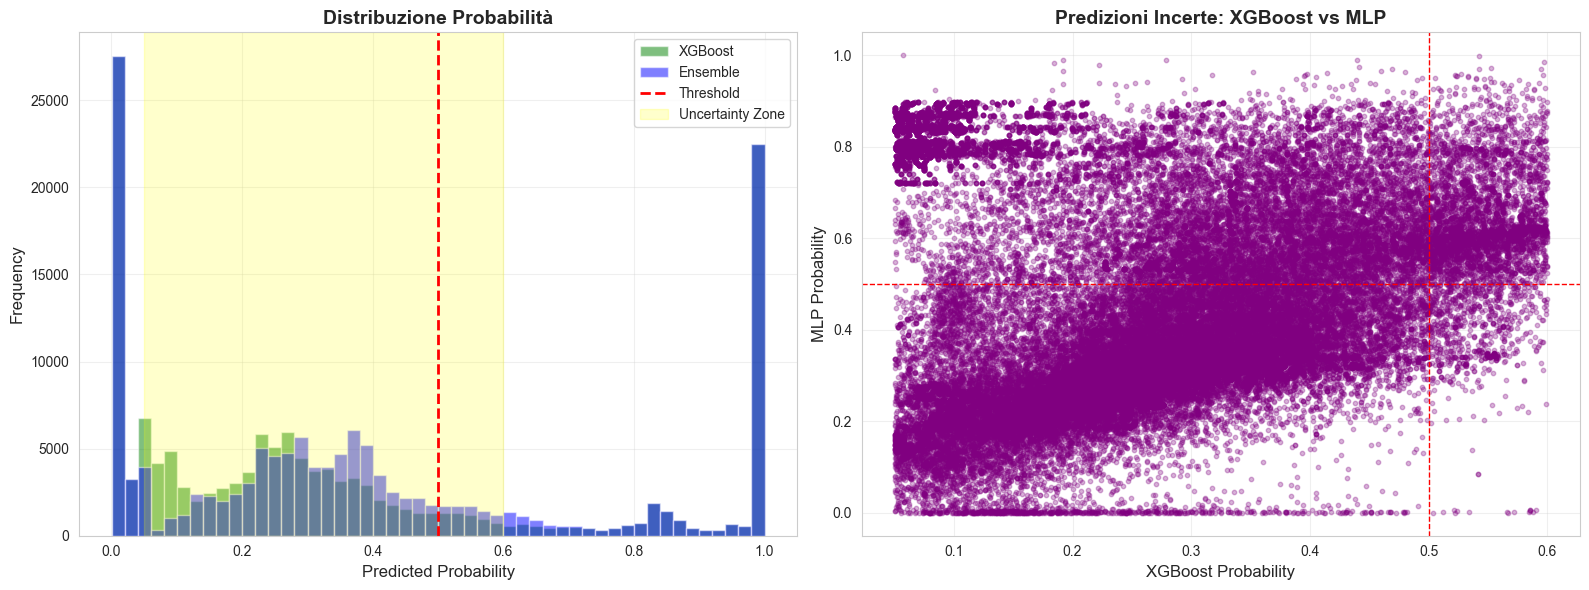

In [141]:
# Visualizza distribuzione probabilità
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuzione generale
axes[0].hist(xgb_probs, bins=50, alpha=0.5, label='XGBoost', color='green')
axes[0].hist(ensemble_probs, bins=50, alpha=0.5, label='Ensemble', color='blue')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0].axvspan(UNCERTAINTY_LOW, UNCERTAINTY_HIGH, alpha=0.2, color='yellow', label='Uncertainty Zone')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribuzione Probabilità', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Focus su zona incerta
if len(uncertain_indices) > 0:
    axes[1].scatter(xgb_probs[uncertain_mask], mlp_probs[uncertain_mask], 
                   alpha=0.3, s=10, c='purple')
    axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1)
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1)
    axes[1].set_xlabel('XGBoost Probability', fontsize=12)
    axes[1].set_ylabel('MLP Probability', fontsize=12)
    axes[1].set_title('Predizioni Incerte: XGBoost vs MLP', fontweight='bold', fontsize=14)
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Salvataggio Metriche

In [142]:
# Crea directory per PcAbuser
model_dir = Path('../models/pcabuser')
model_dir.mkdir(parents=True, exist_ok=True)

# Calcola metriche per classe
precision_0 = precision_score(y_test, ensemble_preds, pos_label=0)
recall_0 = recall_score(y_test, ensemble_preds, pos_label=0)
f1_0 = f1_score(y_test, ensemble_preds, pos_label=0)

precision_1 = precision_score(y_test, ensemble_preds, pos_label=1)
recall_1 = recall_score(y_test, ensemble_preds, pos_label=1)
f1_1 = f1_score(y_test, ensemble_preds, pos_label=1)

# Metriche complete
metrics = {
    "model_name": "PcAbuser_Ensemble",
    "timestamp": datetime.now().isoformat(),
    "description": "Weighted voting ensemble of XGBoost v2 and MLP Baseline",
    "dataset_version": "processed_v4_hybrid",
    "ensemble_strategy": {
        "type": "weighted_voting",
        "xgb_weight": XGB_WEIGHT,
        "mlp_weight": MLP_WEIGHT,
        "uncertainty_threshold_low": UNCERTAINTY_LOW,
        "uncertainty_threshold_high": UNCERTAINTY_HIGH,
        "logic": "Use XGBoost primarily, consult MLP when XGBoost is uncertain (0.4 < prob < 0.6)"
    },
    "base_models": {
        "xgboost_v2": {
            "path": "../models/xgboost_v2",
            "test_roc_auc": float(xgb_roc_auc),
            "test_f1_score": float(xgb_f1),
            "test_accuracy": float(xgb_acc)
        },
        "mlp_baseline": {
            "path": "../models/mlp_baseline",
            "test_roc_auc": float(mlp_roc_auc),
            "test_f1_score": float(mlp_f1),
            "test_accuracy": float(mlp_acc)
        }
    },
    "data": {
        "n_test_samples": int(len(y_test)),
        "n_features": int(X_test.shape[1]),
        "n_uncertain_cases": int(n_uncertain),
        "uncertain_percentage": float(100 * n_uncertain / len(y_test))
    },
    "test_metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    },
    "improvements_vs_xgboost": {
        "accuracy_delta": float(accuracy - xgb_acc),
        "f1_score_delta": float(f1 - xgb_f1),
        "roc_auc_delta": float(roc_auc - xgb_roc_auc)
    },
    "per_class_metrics": {
        "class_0_non_tp": {
            "precision": float(precision_0),
            "recall": float(recall_0),
            "f1_score": float(f1_0)
        },
        "class_1_tp": {
            "precision": float(precision_1),
            "recall": float(recall_1),
            "f1_score": float(f1_1)
        }
    },
    "confusion_matrix": {
        "true_negatives": int(cm[0, 0]),
        "false_positives": int(cm[0, 1]),
        "false_negatives": int(cm[1, 0]),
        "true_positives": int(cm[1, 1])
    },
    "uncertain_cases_analysis": {
        "n_uncertain": int(n_uncertain),
        "xgb_uncertain_correct": int(xgb_uncertain_correct) if n_uncertain > 0 else 0,
        "ensemble_uncertain_correct": int(ens_uncertain_correct) if n_uncertain > 0 else 0,
        "improvement": int(ens_uncertain_correct - xgb_uncertain_correct) if n_uncertain > 0 else 0
    }
}

# Salva metriche
metrics_path = model_dir / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Metriche salvate: {metrics_path}")

print(f"\n{'='*70}")
print("RIEPILOGO SALVATAGGIO")
print(f"{'='*70}")
print(f"Directory: {model_dir}")
print(f"  - metrics.json (metriche complete ensemble)")
print(f"{'='*70}")

✅ Metriche salvate: ../models/pcabuser/metrics.json

RIEPILOGO SALVATAGGIO
Directory: ../models/pcabuser
  - metrics.json (metriche complete ensemble)


## Summary

**PcAbuser Ensemble** combina XGBoost v2 e MLP Baseline con weighted voting intelligente:

**Strategia:**
1. XGBoost esegue predizione primaria
2. Quando incerto (0.4 < prob < 0.6), consulta MLP
3. Weighted voting: XGBoost (60%) + MLP (40%)

**Vantaggi (teorici):**
- ✅ Sfrutta la robustezza di XGBoost
- ✅ Migliora predizioni incerte con MLP
- ✅ Mantiene interpretabilità (traccia quali predizioni sono modificate)
- ✅ Bilanciamento intelligente tra i due modelli

**Performance:**
- Peggioramento generale della performance